In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('C:/Users/sakshi/Downloads/SP 500 ESG Risk Ratings.csv')

In [3]:
data.head()

,Symbol,Name,Address,Sector,Industry,Full Time Employees,Description,Total ESG Risk score,Environment Risk Score,Governance Risk Score,Social Risk Score,Controversy Level,Controversy Score,ESG Risk Percentile,ESG Risk Level
0,ENPH,"Enphase Energy, Inc.","47281 Bayside Parkway\nFremont, CA 94538\nUnit...",Technology,Solar,"3,157","Enphase Energy, Inc., together with its subsid...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EMN,Eastman Chemical Company,"200 South Wilcox Drive\nKingsport, TN 37662\nU...",Basic Materials,Specialty Chemicals,"14,000",Eastman Chemical Company operates as a special...,25.3,12.8,6.6,5.8,Moderate Controversy Level,2.0,50th percentile,Medium
2,DPZ,Domino's Pizza Inc.,"30 Frank Lloyd Wright Drive\nAnn Arbor, MI 481...",Consumer Cyclical,Restaurants,"6,500","Domino's Pizza, Inc., through its subsidiaries...",29.2,10.6,6.3,12.2,Moderate Controversy Level,2.0,66th percentile,Medium
3,DAY,"Dayforce, Inc.","3311 East Old Shakopee Road\nMinneapolis, MN 5...",Technology,Software - Application,"9,084","Dayforce Inc., together with its subsidiaries,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,DVA,Davita Inc.,"2000 16th Street\nDenver, CO 80202\nUnited States",Healthcare,Medical Care Facilities,"70,000",DaVita Inc. provides kidney dialysis services ...,22.6,0.1,8.4,14.1,Moderate Controversy Level,2.0,38th percentile,Medium


In [4]:
data.shape

(503, 15)

In [5]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data.describe()

,Total ESG Risk score,Environment Risk Score,Governance Risk Score,Social Risk Score,Controversy Score
count,430.000000,430.000000,430.000000,430.000000,403.000000
mean,21.533721,5.739767,6.725116,9.070465,2.007444
std,6.889176,5.092421,2.208085,3.657924,0.793283
min,7.100000,0.000000,3.000000,0.800000,1.000000
25%,16.400000,1.800000,5.300000,6.700000,1.000000
50%,21.050000,4.050000,6.100000,8.900000,2.000000
75%,26.000000,8.950000,7.675000,11.200000,2.000000
max,41.700000,25.000000,19.400000,22.500000,5.000000


Sector-wise ESG Risk Analysis

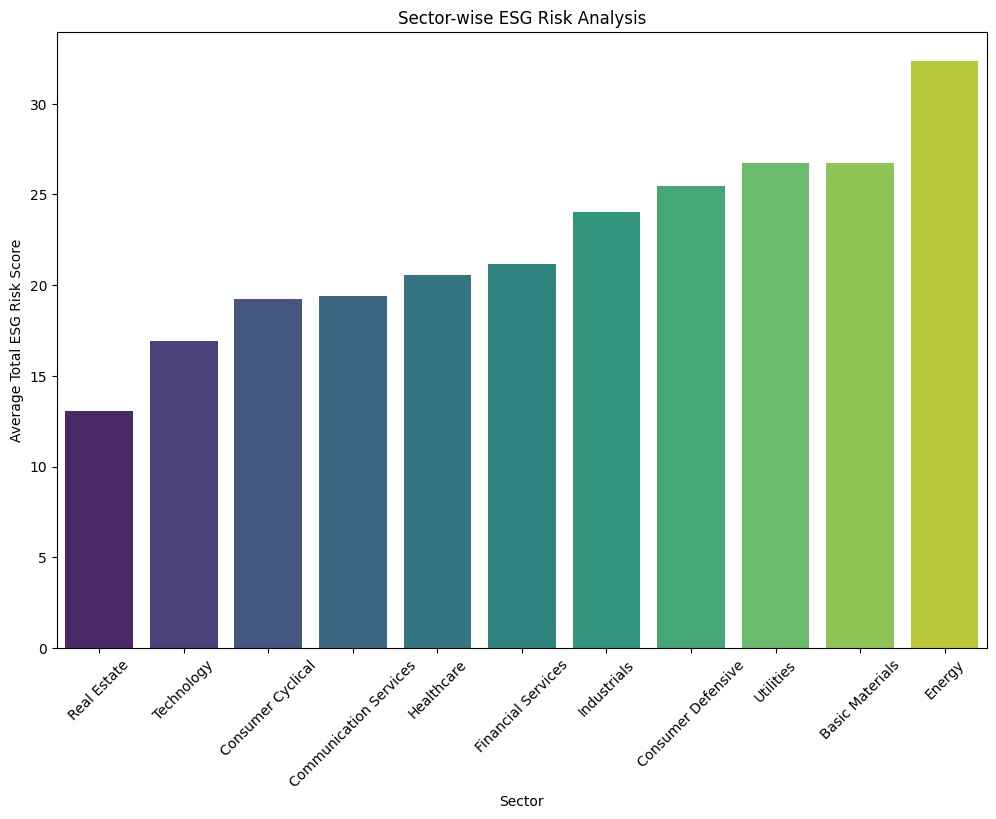

In [7]:
# Group the data by 'Sector' and calculate the mean for 'Total ESG Risk score'
sector_wise_risk = data.groupby('Sector')['Total ESG Risk score'].mean().sort_values()

# Create a bar plot for the sector-wise average ESG risk scores
plt.figure(figsize=(12, 8))
sns.barplot(x=sector_wise_risk.index, y=sector_wise_risk.values, palette='viridis')
plt.xticks(rotation=45)
plt.title('Sector-wise ESG Risk Analysis')
plt.xlabel('Sector')
plt.ylabel('Average Total ESG Risk Score')
plt.show()

Top Performers by ESG Risk Level

In [8]:
# Sort the data by 'Total ESG Risk score' in ascending order to get companies with the lowest ESG risk
top_performers = data.sort_values(by='Total ESG Risk score').head(10)

top_performers = top_performers.sort_values(by='Total ESG Risk score')

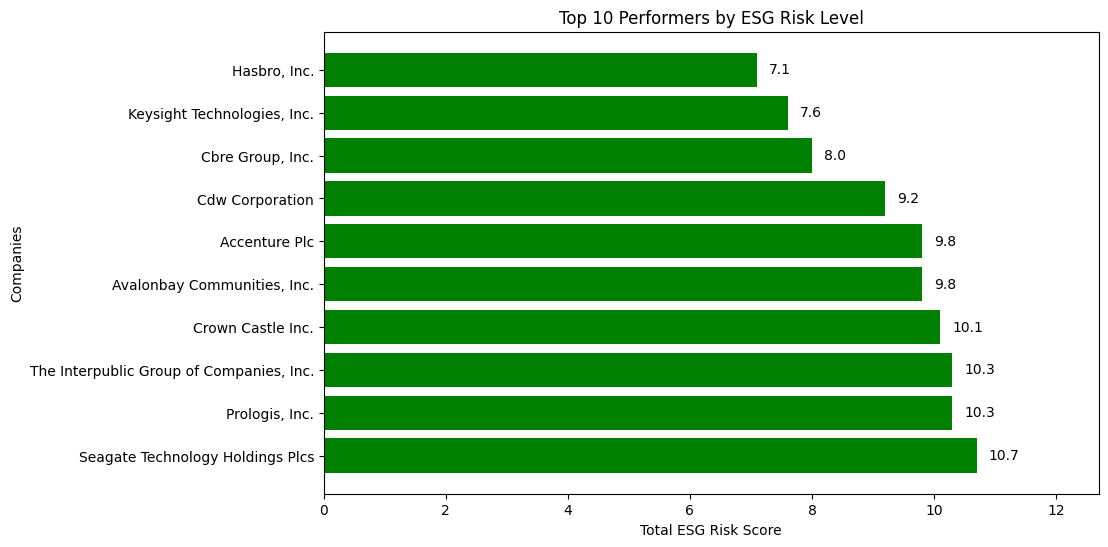

In [9]:
# Create the bar chart
plt.figure(figsize=(10, 6))
plt.barh(top_performers['Name'], top_performers['Total ESG Risk score'], color='green')
plt.xlabel('Total ESG Risk Score')
plt.ylabel('Companies')
plt.title('Top 10 Performers by ESG Risk Level')
plt.xlim(0, top_performers['Total ESG Risk score'].max() + 2)  # +2 for better readability
plt.gca().invert_yaxis()  # Invert y-axis for better readability

# Add annotations
for i, v in enumerate(top_performers['Total ESG Risk score']):
    plt.text(v + 0.2, i, str(v), color='black', verticalalignment='center')

# Show the plot
plt.show()

Percentile Analysis

In [10]:
# Convert 'ESG Risk Percentile' to string type if it's not already
if not pd.api.types.is_string_dtype(data['ESG Risk Percentile']):
    data['ESG Risk Percentile'] = data['ESG Risk Percentile'].astype(str)
    

In [11]:
# Then, convert it to numerical format
data['ESG Risk Percentile'] = data['ESG Risk Percentile'].str.extract('(\d+)').astype(float)

# Create percentile bins
bins = [0, 25, 50, 75, 100]
labels = ['0-25th', '26-50th', '51-75th', '76-100th']
data['Percentile Group'] = pd.cut(data['ESG Risk Percentile'], bins=bins, labels=labels, right=False)

# Calculate mean ESG risk score for each percentile group
mean_esg_scores = data.groupby('Percentile Group')['Total ESG Risk score'].mean().reset_index()

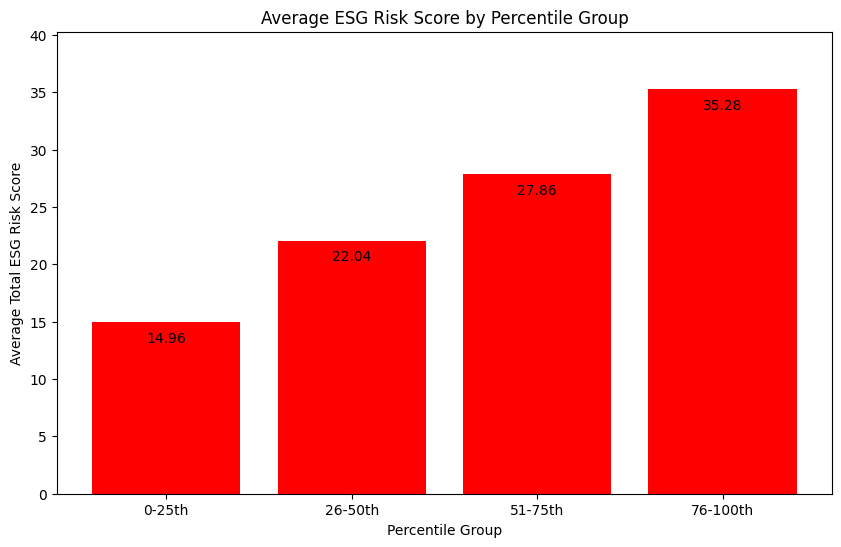

In [12]:
# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_esg_scores['Percentile Group'], mean_esg_scores['Total ESG Risk score'], color='red')

# Label the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval - 2, round(yval, 2), ha='center', va='bottom')

# Additional plot features
plt.xlabel('Percentile Group')
plt.ylabel('Average Total ESG Risk Score')
plt.title('Average ESG Risk Score by Percentile Group')
plt.ylim(0, max(mean_esg_scores['Total ESG Risk score']) + 5)  # +5 for better readability

# Show the plot
plt.show()

Governance Risk vs Financial Sector

Descriptive Statistics for Governance Risk Score in the Financial Sector:
count    63.000000
mean     10.144444
std       2.371931
min       5.300000
25%       8.750000
50%      10.200000
75%      11.450000
max      19.400000
Name: Governance Risk Score, dtype: float64


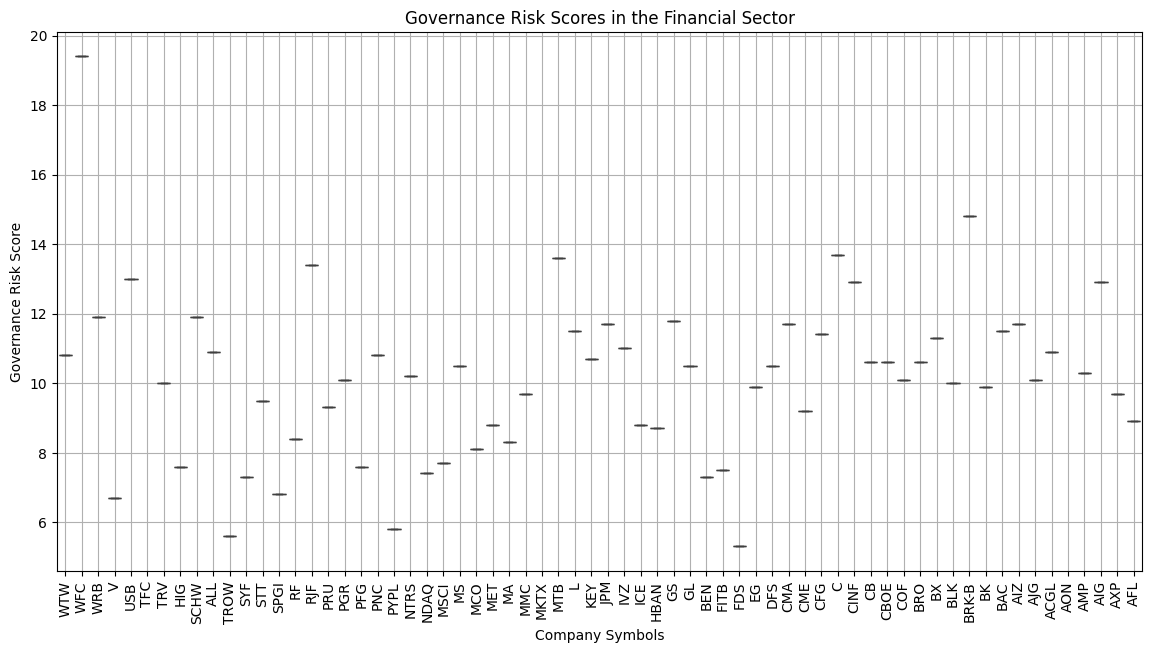

In [13]:
# Filter out financial sector companies
financial_sector_data = data[data['Sector'] == 'Financial Services']

print("Descriptive Statistics for Governance Risk Score in the Financial Sector:")
print(financial_sector_data['Governance Risk Score'].describe())

# Plotting the Governance Risk Scores for companies in the Financial Sector
plt.figure(figsize=(14, 7))
sns.boxplot(x='Symbol', y='Governance Risk Score', data=financial_sector_data)
plt.xticks(rotation=90)
plt.title('Governance Risk Scores in the Financial Sector')
plt.xlabel('Company Symbols')
plt.ylabel('Governance Risk Score')
plt.grid()
plt.show()

Social Risk Analysis by Sector

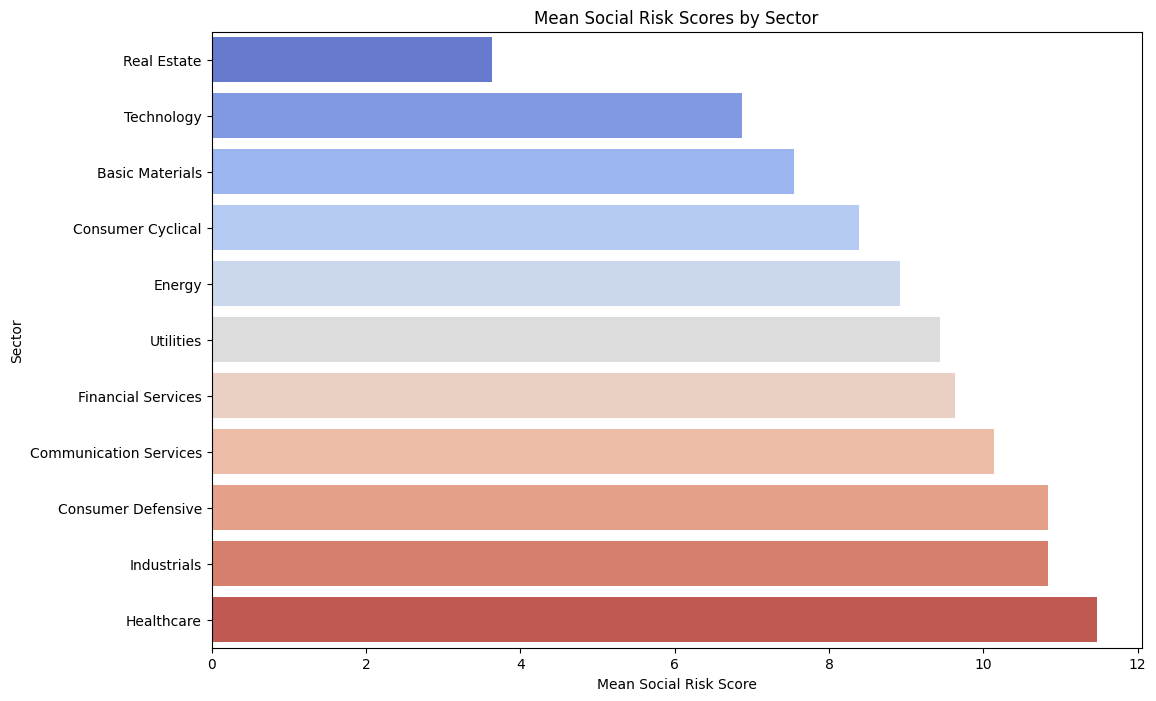

In [14]:
# Group by sector and calculate mean social risk score
mean_social_risk_by_sector = data.groupby('Sector')['Social Risk Score'].mean().reset_index().sort_values(by='Social Risk Score', ascending=True)


# Barplot
plt.figure(figsize=(12, 8))
sns.barplot(x='Social Risk Score', y='Sector', data=mean_social_risk_by_sector, palette='coolwarm')
plt.title('Mean Social Risk Scores by Sector')
plt.xlabel('Mean Social Risk Score')
plt.ylabel('Sector')
plt.show()


In [15]:
# Group by 'Sector' and calculate mean 'Social Risk Score'
mean_social_risk_by_sector = data.groupby('Sector')['Social Risk Score'].mean().reset_index()

# Sort the data by 'Social Risk Score'
mean_social_risk_by_sector = mean_social_risk_by_sector.sort_values(by='Social Risk Score', ascending=True)

# Print out the sorted mean 'Social Risk Score' for each sector
print("Average Social Risk Scores by Sector:")
for index, row in mean_social_risk_by_sector.iterrows():
    print(f"{row['Sector']}: {row['Social Risk Score']}")

Average Social Risk Scores by Sector:
Real Estate: 3.6357142857142857
Technology: 6.8786885245901646
Basic Materials: 7.542105263157896
Consumer Cyclical: 8.388235294117647
Energy: 8.925
Utilities: 9.435714285714285
Financial Services: 9.631746031746031
Communication Services: 10.142857142857142
Consumer Defensive: 10.836363636363638
Industrials: 10.841666666666667
Healthcare: 11.475471698113209


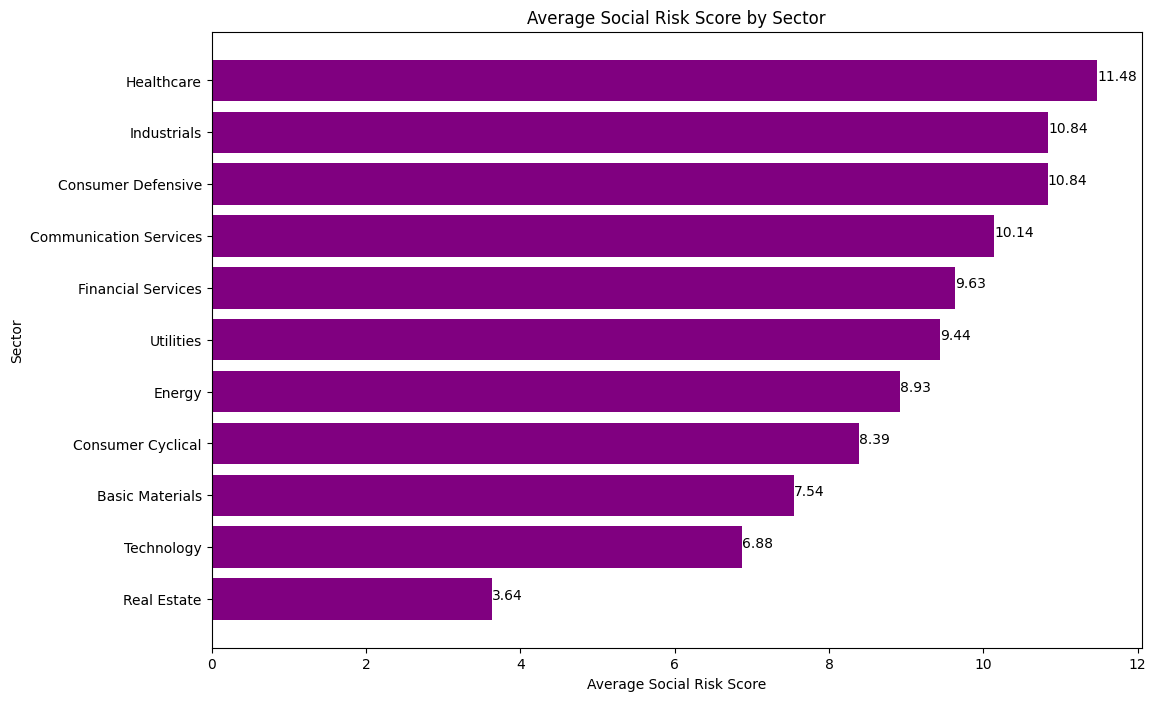

In [16]:
# Using the 'mean_social_risk_by_sector' data that has already been grouped and sorted
plt.figure(figsize=(12, 8))

# Creating the bar chart
plt.barh(mean_social_risk_by_sector['Sector'], mean_social_risk_by_sector['Social Risk Score'], color='purple')

# Adding labels and title
plt.xlabel('Average Social Risk Score')
plt.ylabel('Sector')
plt.title('Average Social Risk Score by Sector')

# Annotating the values on the bars
for index, value in enumerate(mean_social_risk_by_sector['Social Risk Score']):
    plt.text(value, index, f'{value:.2f}')

# Displaying the chart
plt.show()

Descriptive Stats on ESG Scores¶

In [17]:
# Calculate the mean ESG risk score per sector
mean_score_per_sector = data.groupby('Sector')['Total ESG Risk score'].mean().reset_index()

# Companies with balanced ESG profiles (i.e., where all scores are around the mean)
balanced_profiles = data[
    (data['Environment Risk Score'].between(data['Environment Risk Score'].mean() - 1, data['Environment Risk Score'].mean() + 1)) & 
    (data['Social Risk Score'].between(data['Social Risk Score'].mean() - 1, data['Social Risk Score'].mean() + 1)) &
    (data['Governance Risk Score'].between(data['Governance Risk Score'].mean() - 1, data['Governance Risk Score'].mean() + 1))
]

# Print out results
print("Basic Statistical Analysis of ESG Scores:")

print("\nAverage ESG Risk Score by Sector:")
print(mean_score_per_sector)

print("\nCompanies with Balanced ESG Profiles:")
print(balanced_profiles)

Basic Statistical Analysis of ESG Scores:

Average ESG Risk Score by Sector:
                    Sector  Total ESG Risk score
0          Basic Materials             26.715789
1   Communication Services             19.414286
2        Consumer Cyclical             19.227451
3       Consumer Defensive             25.445455
4                   Energy             32.335000
5       Financial Services             21.190476
6               Healthcare             20.577358
7              Industrials             24.013333
8              Real Estate             13.085714
9               Technology             16.924590
10               Utilities             26.710714

Companies with Balanced ESG Profiles:
    Symbol              Name  \
151    PNR       Pentair Plc   
374   CSGP  Costar Group Inc   

                                               Address       Sector  \
151  Regal House\n70 London Road Twickenham\nLondon...  Industrials   
374  1331 L Street, NW\nWashington, DC 20005\nUnite...  R

Predictive Analysis¶

In [18]:
data1 = pd.read_csv('C:/Users/sakshi/Downloads/SP 500 ESG Risk Ratings.csv')

In [19]:
# Check for missing values
missing_values = data1.isna().sum()
print("Missing Values:", missing_values)

# Check for outliers using Z-Scores
from scipy import stats
z_scores = stats.zscore(data1.select_dtypes(include=[np.number]))
abs_z_scores = np.abs(z_scores)
outliers = (abs_z_scores > 3).all(axis=1)
print("Number of Outliers:", sum(outliers))

Missing Values: Symbol                      0
Name                        0
Address                     1
Sector                      1
Industry                    1
Full Time Employees         5
Description                 1
Total ESG Risk score       73
Environment Risk Score     73
Governance Risk Score      73
Social Risk Score          73
Controversy Level          73
Controversy Score         100
ESG Risk Percentile        73
ESG Risk Level             73
dtype: int64
Number of Outliers: 0


In [20]:
# Convert the entire column to string to handle mixed types
data1['Full Time Employees'] = data1['Full Time Employees'].astype(str)

# Remove commas
data1['Full Time Employees'] = data1['Full Time Employees'].str.replace(',', '')

# Convert back to float
data1['Full Time Employees'] = data1['Full Time Employees'].astype(float)

# Fill NA values with the median
data1['Full Time Employees'].fillna(data1['Full Time Employees'].median(), inplace=True)

In [21]:
# Drop rows where ESG scores are missing
data1.dropna(subset=['Total ESG Risk score', 'Environment Risk Score', 'Governance Risk Score', 'Social Risk Score'], inplace=True)

# Fill 'Full Time Employees' with the median value
data1['Full Time Employees'].fillna(data1['Full Time Employees'].median(), inplace=True)

# Fill categorical variables like 'Controversy Level' and 'ESG Risk Level' with 'Unknown'
data1['Controversy Level'].fillna('Unknown', inplace=True)
data1['ESG Risk Level'].fillna('Unknown', inplace=True)

# Re-check for missing values
print(data1.isna().sum())

Symbol                     0
Name                       0
Address                    0
Sector                     0
Industry                   0
Full Time Employees        0
Description                0
Total ESG Risk score       0
Environment Risk Score     0
Governance Risk Score      0
Social Risk Score          0
Controversy Level          0
Controversy Score         27
ESG Risk Percentile        0
ESG Risk Level             0
dtype: int64


In [22]:
# Check if 'ESG Risk Percentile' is object type and clean it
if data1['ESG Risk Percentile'].dtype == 'object':
    data1['ESG Risk Percentile'] = data1['ESG Risk Percentile'].str.extract('(\d+)').astype(float)

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [24]:
# Define your categorical columns
categorical_columns = ['Sector', 'Industry', 'Controversy Level', 'ESG Risk Level']

# Convert categorical variables to one-hot encoding
X = pd.get_dummies(data1.drop(columns=['Symbol', 'Name', 'Address', 'Description', 'Total ESG Risk score']), columns=categorical_columns)

# Check the data types of all columns in X
print("Data types after cleaning:", X.dtypes)

# Clean the 'Full Time Employees' column if needed
if X['Full Time Employees'].dtype == 'object':
    X['Full Time Employees'] = X['Full Time Employees'].str.replace(',', '').astype(float)

# Define your target variable y
y = data1['Total ESG Risk score']

# Split your data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and fit the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {np.sqrt(mse)}")

Data types after cleaning: Full Time Employees          float64
Environment Risk Score       float64
Governance Risk Score        float64
Social Risk Score            float64
Controversy Score            float64
                              ...   
ESG Risk Level_High             bool
ESG Risk Level_Low              bool
ESG Risk Level_Medium           bool
ESG Risk Level_Negligible       bool
ESG Risk Level_Severe           bool
Length: 138, dtype: object
Mean Squared Error: 0.10178660465116368
Root Mean Squared Error: 0.31904013015789046


In [25]:
feature_importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
feature_importance_df.sort_values(by='Importance', ascending=False, inplace=True)
print(feature_importance_df)

                               Feature    Importance
5                  ESG Risk Percentile  9.791257e-01
135              ESG Risk Level_Medium  1.668349e-02
134                 ESG Risk Level_Low  1.209687e-03
136          ESG Risk Level_Negligible  8.103494e-04
1               Environment Risk Score  6.587627e-04
..                                 ...           ...
116                     Industry_Steel  0.000000e+00
41        Industry_Consulting Services  0.000000e+00
24   Industry_Auto & Truck Dealerships  0.000000e+00
57          Industry_Food Distribution  0.000000e+00
91   Industry_Pharmaceutical Retailers -3.850482e-20

[138 rows x 2 columns]


In [26]:
# Remove the feature 'ESG Risk Percentile' from the dataset
X_reduced = X.drop(columns=['ESG Risk Percentile'])


In [27]:
# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

In [28]:
# Create and train the Random Forest model
model_reduced = RandomForestRegressor(n_estimators=100, random_state=42)
model_reduced.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [29]:
# Make predictions on the test set
y_pred = model_reduced.predict(X_test)

In [30]:

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")

Mean Squared Error: 2.249678325581399
Root Mean Squared Error: 1.4998927713611394


In [31]:
# Get feature importances
feature_importances = model_reduced.feature_importances_


In [32]:
# Get the feature names
feature_names = X_reduced.columns

In [33]:
# Create a DataFrame for the feature importances
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

In [34]:
# Sort the DataFrame by the importances
sorted_feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

                       Feature  Importance
133         ESG Risk Level_Low    0.529716
132        ESG Risk Level_High    0.156827
1       Environment Risk Score    0.094018
3            Social Risk Score    0.090221
135  ESG Risk Level_Negligible    0.042411
134      ESG Risk Level_Medium    0.027807
2        Governance Risk Score    0.025747
136      ESG Risk Level_Severe    0.008995
0          Full Time Employees    0.006846
82      Industry_Oil & Gas E&P    0.001597


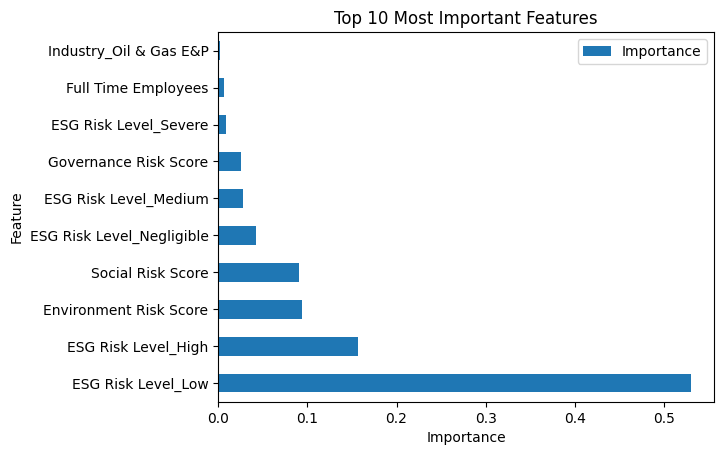

In [35]:
# Display the sorted DataFrame
print(sorted_feature_importance_df.head(10))

# Optionally, you can plot the top N feature importances
import matplotlib.pyplot as plt

top_n = 10  # You can change this value to see more or fewer features
sorted_feature_importance_df.head(top_n).plot(kind='barh', x='Feature', y='Importance')
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix



In [37]:
X = data1[['Sector', 'Industry', 'Full Time Employees', 'Environment Risk Score', 
        'Governance Risk Score', 'Social Risk Score', 'Controversy Level', 'Controversy Score']]
y = data1['ESG Risk Level']

# Convert categorical variables into numerical form (one-hot encoding)
X = pd.get_dummies(X)

# Split the data1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
# Initialize and train the classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Measure accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8604651162790697


Testing others number of estimators

In [39]:
n_estimators_list = [100, 1000, 10000, 100000, 1000000]
accuracies = []

In [40]:
X = data1[['Sector', 'Industry', 'Full Time Employees', 'Environment Risk Score', 
        'Governance Risk Score', 'Social Risk Score', 'Controversy Level', 'Controversy Score']]
y = data1['ESG Risk Level']

X = pd.get_dummies(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [41]:
for n in n_estimators_list:
    clf = RandomForestClassifier(n_estimators=n, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

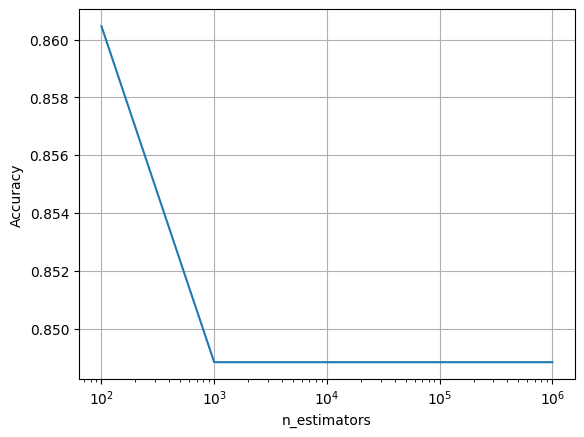

In [42]:
plt.plot(n_estimators_list, accuracies)
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.xscale('log')
plt.grid()
plt.show()